<h1 style="text-align:center; font-size: 5em;">Project: Python Game Development</h1>
<hr style="border:2px solid">
<h1 style="text-align:center; font-size: 3em;">Project Overview</h1>
<hr style="border-top:1px dashed">


## Welcome to the First Python Project! 

Create a simple and interactive game using Python, incorporating fundamental programming concepts and Python basics. This project aims to reinforce your understanding of core Python principles while fostering creativity through game development. 

### Game options:

#### Guess the Number:

The computer randomly selects a number, and the player has to guess it.
Provide hints like "too high" or "too low" after each guess.
Include a limited number of attempts and a score system based on accuracy.

#### Hangman:

Create a word bank and randomly select a word for the player to guess.
Display the current state of the word with blanks for unrevealed letters.
Allow a limited number of incorrect guesses before the game ends.

#### Tic-Tac-Toe:

Implement a two-player Tic-Tac-Toe game.
Ensure proper input validation and display the game board after each move.
Declare the winner or a draw when the game concludes.

__Note: you can explore implementiong any other game of your choice.__


## Requirements

This project has two types of requirements:

### Technical Requirements:
Technical Requirements are designed to guide you on your project. These will help point you in the right direction as well as show you what we will be looking for when reviewing your project. These requirements will be focused towards the specific coding aspects you use.

### Functional Requirements:
Functional Requirements are designed to provoke thought throughout your project. These will be based in theory rather than code. These requirements will assist in shaping your output of each task.

#### Make sure to read the instructions thoroughly.

<hr style="border:2px solid">
<h1 style="text-align:center; font-size: 3em;">Project Requirements</h1>
<hr style="border-top:1px dashed">

### Functional Requirements:

- Use functions to modularise your code and promote code readability.
- Implement proper error handling for user inputs to avoid crashes.
- Ensure the game provides clear instructions and feedback to the player.
- Add comments to explain complex sections of your code.
- Create a README file that includes instructions on how to play the game.
- Have statistics of the games. 

__Optional:__ 

- Implement a graphical user interface (GUI) using libraries like Pygame or Tkinter.
- Add sound effects or background music to enhance the gaming experience.
- Create additional levels or features to make the game more challenging.

### Code Requirements:

This project will require an assortment of counter variables that will have to be set on a global scale (they exist outside of all functions). It will also be required to use at least two function that you write. I would recommend you create the barebones of the game, then pretty it up. Do not worry about making incredibly detailed print statements and formatting until you finish the base game.

- Provide flowchart.
- Write at least two functions.
- Check the user input for any types of non-numeric answers or those that are not expected by the program (when applicable).
- Use several global counters to keep track of user's statistics.
- Code must have comment's explaining what you did following coding style standars and documentaton best practices.


### Deliverables: 

- Flowchart.
- Python script or Jupyter Notebook with the game.
- GitHub Repo.
- README file.
- Up to 3 min video presentation sowcasing the game.

***Note on AI Use***: 
We understand that AI tools can be helpful in coding, and we do not discourage their use. However, for this project, we strongly encourage you to minimise your reliance on AI. This is a crucial stage in your learning journey, and working through the problems yourself will help you build a solid understanding of Python fundamentals. Overusing AI at this point may hinder your ability to grasp key concepts and develop problem-solving skills that are essential for your growth as a programmer.


<hr style="border:2px solid">

In [2]:
%pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---

### Part One:
> Please provide the Flowchart of your solution.

> These do not need to be overly detailed. Create basic short steps.


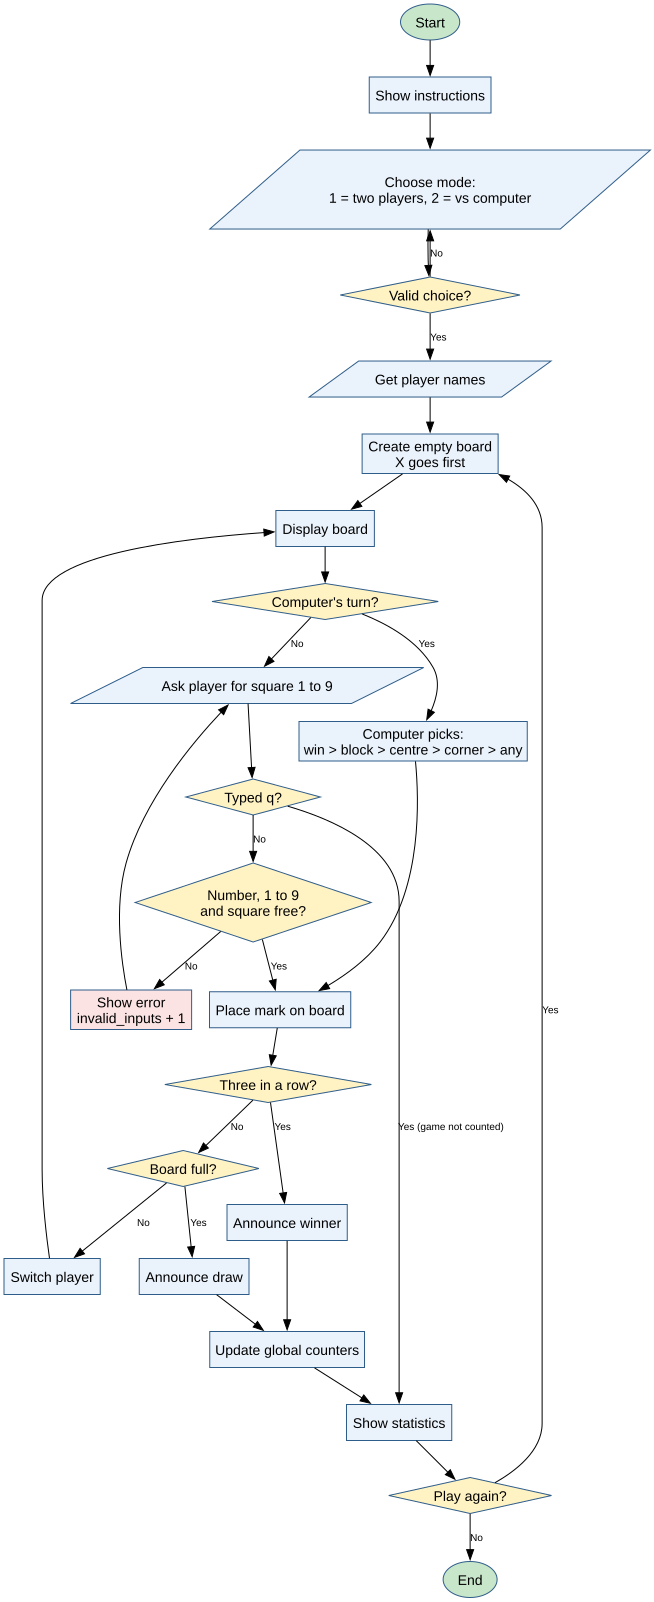

In [4]:
# Flowchart of the Tic Tac Toe game, drawn with Graphviz.
import os
from graphviz import Digraph

# Tell Python where Graphviz is installed on Windows.
GRAPHVIZ_PATH = r"C:\Program Files\Graphviz\bin"
if not os.path.exists(os.path.join(GRAPHVIZ_PATH, "dot.exe")):
    print("Graphviz not found. Run 'winget install graphviz' in the terminal first.")
os.environ["PATH"] += os.pathsep + GRAPHVIZ_PATH

chart = Digraph(graph_attr={"rankdir": "TB", "fontname": "Arial"},
                node_attr={"fontname": "Arial", "style": "filled",
                           "fillcolor": "#EAF2FB", "color": "#2F5D8A"},
                edge_attr={"fontname": "Arial", "fontsize": "10"})

decision = {"shape": "diamond", "fillcolor": "#FFF3C4"}
terminal = {"shape": "oval", "fillcolor": "#C8E6C9"}

# Nodes
chart.node("start", "Start", **terminal)
chart.node("instr", "Show instructions", shape="box")
chart.node("mode", "Choose mode:\n1 = two players, 2 = vs computer", shape="parallelogram")
chart.node("modeok", "Valid choice?", **decision)
chart.node("names", "Get player names", shape="parallelogram")
chart.node("newb", "Create empty board\nX goes first", shape="box")
chart.node("show", "Display board", shape="box")
chart.node("comp", "Computer's turn?", **decision)
chart.node("cmove", "Computer picks:\nwin > block > centre > corner > any", shape="box")
chart.node("ask", "Ask player for square 1 to 9", shape="parallelogram")
chart.node("quit", "Typed q?", **decision)
chart.node("valid", "Number, 1 to 9\nand square free?", **decision)
chart.node("err", "Show error\ninvalid_inputs + 1", shape="box", fillcolor="#FBE3E3")
chart.node("place", "Place mark on board", shape="box")
chart.node("win", "Three in a row?", **decision)
chart.node("full", "Board full?", **decision)
chart.node("swap", "Switch player", shape="box")
chart.node("winner", "Announce winner", shape="box")
chart.node("draw", "Announce draw", shape="box")
chart.node("stats", "Update global counters", shape="box")
chart.node("showst", "Show statistics", shape="box")
chart.node("again", "Play again?", **decision)
chart.node("end", "End", **terminal)

# Connections
chart.edges([("start", "instr"), ("instr", "mode"), ("mode", "modeok"),
             ("names", "newb"), ("newb", "show"), ("show", "comp"),
             ("ask", "quit"), ("err", "ask"), ("cmove", "place"),
             ("place", "win"), ("swap", "show"), ("winner", "stats"),
             ("draw", "stats"), ("stats", "showst"), ("showst", "again")])
chart.edge("modeok", "mode", label="No")
chart.edge("modeok", "names", label="Yes")
chart.edge("comp", "cmove", label="Yes")
chart.edge("comp", "ask", label="No")
chart.edge("quit", "showst", label="Yes (game not counted)")
chart.edge("quit", "valid", label="No")
chart.edge("valid", "err", label="No")
chart.edge("valid", "place", label="Yes")
chart.edge("win", "winner", label="Yes")
chart.edge("win", "full", label="No")
chart.edge("full", "draw", label="Yes")
chart.edge("full", "swap", label="No")
chart.edge("again", "newb", label="Yes")
chart.edge("again", "end", label="No")

chart  # displays the flowchart in the notebook

---

### Part Two:
> Build it!

> Write your code below.

> Work towards a minimal viable product before working on making your output pretty.

In [5]:
"""
Tic Tac Toe
===========

A command line Tic Tac Toe game written in Python.

Features
--------
* Two player mode (player vs player on the same keyboard).
* Single player mode against a computer opponent.
* Input validation so the game never crashes on bad input.
* Session statistics tracked with global counters.
"""

import random

# ---------------------------------------------------------------------------
# Global statistics counters
# These live outside every function so they persist across games in a session.
# Functions that change them declare them with the `global` keyword.
# ---------------------------------------------------------------------------
games_played = 0
x_wins = 0
o_wins = 0
draws = 0
total_moves = 0
invalid_inputs = 0

# Every combination of board positions that counts as three in a row.
# The board is a list of 9 cells, indexed 0 to 8:
#   0 | 1 | 2
#   3 | 4 | 5
#   6 | 7 | 8
WINNING_LINES = [
    (0, 1, 2), (3, 4, 5), (6, 7, 8),  # rows
    (0, 3, 6), (1, 4, 7), (2, 5, 8),  # columns
    (0, 4, 8), (2, 4, 6),             # diagonals
]


def show_instructions():
    """Print the rules and explain how to choose a square."""
    print("\n" + "=" * 40)
    print("          WELCOME TO TIC TAC TOE")
    print("=" * 40)
    print("Two players take turns placing X and O on a 3x3 grid.")
    print("Get three of your marks in a row, column or diagonal to win.")
    print("If all nine squares fill up with no winner, the game is a draw.")
    print("\nChoose a square by typing its number:")
    print(" 1 | 2 | 3 ")
    print("---+---+---")
    print(" 4 | 5 | 6 ")
    print("---+---+---")
    print(" 7 | 8 | 9 ")
    print("\nType 'q' at any time during a move to quit the current game.")


def create_board():
    """Return a new empty board as a list of 9 spaces."""
    return [" "] * 9


def display_board(board):
    """Print the board, showing square numbers in empty cells as a guide."""
    print()
    for row in range(3):
        cells = []
        for col in range(3):
            index = row * 3 + col
            # Show the square number if empty so players know what to type.
            cells.append(board[index] if board[index] != " " else str(index + 1))
        print(" " + " | ".join(cells))
        if row < 2:
            print("---+---+---")
    print()


def get_menu_choice(prompt, valid_options):
    """
    Keep asking until the user types one of the valid options.

    Args:
        prompt (str): The question shown to the user.
        valid_options (list[str]): Accepted answers, in lower case.

    Returns:
        str: The chosen option in lower case.
    """
    global invalid_inputs
    while True:
        choice = input(prompt).strip().lower()
        if choice in valid_options:
            return choice
        invalid_inputs += 1
        print(f"Please enter one of: {', '.join(valid_options)}")


def get_player_name(label):
    """Ask for a player's name, falling back to a default if left blank."""
    name = input(f"Enter a name for {label} (press Enter for '{label}'): ").strip()
    return name if name else label


def get_player_move(board, player_name, mark):
    """
    Ask a human player for a square and validate it.

    Rejects text that is not a number, numbers outside 1 to 9,
    and squares that are already taken.

    Args:
        board (list[str]): The current board.
        player_name (str): Name shown in the prompt.
        mark (str): 'X' or 'O'.

    Returns:
        int | None: Board index 0 to 8, or None if the player quits.
    """
    global invalid_inputs
    while True:
        answer = input(f"{player_name} ({mark}), choose a square 1 to 9: ").strip().lower()

        if answer == "q":
            return None

        # Catch anything that cannot be turned into a whole number.
        try:
            square = int(answer)
        except ValueError:
            invalid_inputs += 1
            print("That is not a number. Please type a number from 1 to 9.")
            continue

        if square < 1 or square > 9:
            invalid_inputs += 1
            print("That square does not exist. Please choose 1 to 9.")
            continue

        index = square - 1  # convert from 1 to 9 for players to 0 to 8 for the list
        if board[index] != " ":
            invalid_inputs += 1
            print("That square is already taken. Try another one.")
            continue

        return index


def find_winning_move(board, mark):
    """Return an index that would complete three in a row for `mark`, or None."""
    for a, b, c in WINNING_LINES:
        line = [board[a], board[b], board[c]]
        # Two of our marks plus one empty square means we can finish the line.
        if line.count(mark) == 2 and line.count(" ") == 1:
            return (a, b, c)[line.index(" ")]
    return None


def get_computer_move(board, computer_mark, player_mark):
    """
    Choose a move for the computer using simple rules, in order:
    1. Win if possible.
    2. Block the player if they are about to win.
    3. Take the centre.
    4. Take a random corner.
    5. Take any remaining square.
    """
    move = find_winning_move(board, computer_mark)
    if move is not None:
        return move

    move = find_winning_move(board, player_mark)
    if move is not None:
        return move

    if board[4] == " ":
        return 4

    corners = [i for i in (0, 2, 6, 8) if board[i] == " "]
    if corners:
        return random.choice(corners)

    return random.choice([i for i in range(9) if board[i] == " "])


def check_winner(board, mark):
    """Return True if `mark` has three in a row anywhere on the board."""
    return any(board[a] == board[b] == board[c] == mark for a, b, c in WINNING_LINES)


def is_board_full(board):
    """Return True if there are no empty squares left."""
    return " " not in board


def update_statistics(result):
    """
    Update the global counters after a finished game.

    Args:
        result (str): 'X', 'O' or 'draw'.
    """
    global games_played, x_wins, o_wins, draws
    games_played += 1
    if result == "X":
        x_wins += 1
    elif result == "O":
        o_wins += 1
    else:
        draws += 1


def show_statistics():
    """Print a summary of every game played in this session."""
    print("\n" + "=" * 40)
    print("           SESSION STATISTICS")
    print("=" * 40)
    print(f"Games played:      {games_played}")
    print(f"X wins:            {x_wins}")
    print(f"O wins:            {o_wins}")
    print(f"Draws:             {draws}")
    if games_played > 0:
        average = total_moves / games_played
        print(f"Average moves:     {average:.1f} per game")
        print(f"X win rate:        {x_wins / games_played:.0%}")
        print(f"O win rate:        {o_wins / games_played:.0%}")
    print(f"Invalid inputs:    {invalid_inputs}")
    print("=" * 40)


def play_game(player_names, computer_mark=None):
    """
    Play one full game and return the result.

    Args:
        player_names (dict): Maps 'X' and 'O' to display names.
        computer_mark (str | None): 'O' if the computer plays O, otherwise None.

    Returns:
        str | None: 'X', 'O', 'draw', or None if a player quit.
    """
    global total_moves
    board = create_board()
    current_mark = "X"  # X always goes first
    moves_this_game = 0  # only added to the global total if the game finishes

    while True:
        display_board(board)

        if current_mark == computer_mark:
            player_mark = "X" if computer_mark == "O" else "O"
            move = get_computer_move(board, computer_mark, player_mark)
            print(f"{player_names[current_mark]} chooses square {move + 1}.")
        else:
            move = get_player_move(board, player_names[current_mark], current_mark)
            if move is None:
                print("Game abandoned. It will not count towards the statistics.")
                return None

        board[move] = current_mark
        moves_this_game += 1

        # Check for a result straight after each move.
        if check_winner(board, current_mark):
            display_board(board)
            print(f"*** {player_names[current_mark]} ({current_mark}) wins! ***")
            total_moves += moves_this_game
            return current_mark

        if is_board_full(board):
            display_board(board)
            print("*** It's a draw! ***")
            total_moves += moves_this_game
            return "draw"

        # Hand the turn to the other player.
        current_mark = "O" if current_mark == "X" else "X"


def main():
    """Run the menu loop: set up players, play games and show statistics."""
    show_instructions()

    mode = get_menu_choice("\nPlay against (1) another player or (2) the computer? ", ["1", "2"])
    if mode == "1":
        player_names = {"X": get_player_name("Player X"), "O": get_player_name("Player O")}
        computer_mark = None
    else:
        player_names = {"X": get_player_name("Player X"), "O": "Computer"}
        computer_mark = "O"

    while True:
        result = play_game(player_names, computer_mark)
        if result is not None:
            update_statistics(result)
        show_statistics()

        again = get_menu_choice("\nPlay again? (y/n): ", ["y", "n", "yes", "no"])
        if again in ("n", "no"):
            break

    print("\nThanks for playing Tic Tac Toe. Goodbye!")

In [ ]:
main()


          WELCOME TO TIC TAC TOE
Two players take turns placing X and O on a 3x3 grid.
Get three of your marks in a row, column or diagonal to win.
If all nine squares fill up with no winner, the game is a draw.

Choose a square by typing its number:
 1 | 2 | 3 
---+---+---
 4 | 5 | 6 
---+---+---
 7 | 8 | 9 

Type 'q' at any time during a move to quit the current game.

 1 | 2 | 3
---+---+---
 4 | 5 | 6
---+---+---
 7 | 8 | 9


 X | 2 | 3
---+---+---
 4 | 5 | 6
---+---+---
 7 | 8 | 9


 X | 2 | O
---+---+---
 4 | 5 | 6
---+---+---
 7 | 8 | 9


 X | 2 | O
---+---+---
 X | 5 | 6
---+---+---
 7 | 8 | 9


 X | 2 | O
---+---+---
 X | O | 6
---+---+---
 7 | 8 | 9


 X | 2 | O
---+---+---
 X | O | X
---+---+---
 7 | 8 | 9


 X | 2 | O
---+---+---
 X | O | X
---+---+---
 O | 8 | 9

*** alex (O) wins! ***

           SESSION STATISTICS
Games played:      1
X wins:            0
O wins:            1
Draws:             0
Average moves:     6.0 per game
X win rate:        0%
O win rate:        10

### Python Game Project

| Subject                                   | 1–2 Marks                                                                                                                                                                                                 | 3–4 Marks                                                                                                                                                                                                 | 5 Marks                                                                                                                                                                                                                  |
|--------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Game Logic & Design (Flowchart)**        | Flowchart is unclear, incomplete, or does not represent the game logic accurately. Major steps or decisions are missing, or the flow is confusing and hard to follow.                                     | Flowchart covers most main steps and decisions, but may have some missing elements or minor clarity issues. Logic is mostly correct but could be clearer.                                                | Flowchart is clear, complete, and accurately represents the game’s logic and structure. All key decisions and steps are included, and the flow is easy to follow.                                                        |
| **Technical Implementation & Effectiveness** | Functions are missing, poorly structured, or not used appropriately. Code does not follow best practices (e.g., poor naming, repetition, lack of modularity). Game does not work as intended, has major errors, or is not engaging. Poor error handling. | Functions are present and mostly appropriate, but may lack clarity or consistency. Some best practices are followed, but there are areas for improvement. Game mostly works, but may have some issues or lack engagement. Some error handling present. | Functions are well-designed, clearly named, and used effectively to structure the code. Code follows best practices throughout, is clean, well-organised, and easy to read. Game works well, is engaging, and handles errors effectively. |
| **Documentation & Presentation**           | Code is difficult to read, poorly commented, and lacks docstrings. Variable and function names are unclear. No or minimal documentation. README file is missing or unhelpful. Presentation is missing or unclear.             | Some comments and docstrings are present, but may lack detail or consistency. Code is somewhat readable, but could be improved. README file is present but basic or incomplete. Presentation covers basics but lacks detail or clarity.                   | Code is well-documented, with comprehensive comments and clear docstrings. Naming is clear and consistent. README file is clear, detailed, and helpful. Presentation is clear, confident, and explains the game’s features and logic well.              |
